# Calage du modèle de crue par moindres carrés non linéaires

Le modèle de crue n'est pas identifiable. 
En effet, le modèle est :
$$
\alpha = \frac{Z_m - Z_v}{L},
$$
if $Z_m \geq Z_v$. 
The height of the river is:
$$
H = \left(\frac{Q}{K_s B \sqrt{\alpha}}\right)^{0.6},
$$
for any $K_s, Q>0$.

On cherche à estimer le vecteur de paramètres
$$
\theta = (K_s, Z_v, Z_m)^T \in \mathbb{R}^3.
$$
La dimension du problème est de dimension 3.
La hauteur dépend du produit $K_s \sqrt{\alpha}$ et $\alpha$ dépend de $Z_m$ et $Z_v$. 

Par conséquent, seul le produit 
$$
K_s \sqrt{Z_m - Z_v}
$$
est identifiable.
Le rang du problème est égal à 1 : on peut estimer $K_s$ ou bien $Z_v$ ou bien $Z_m$, mais on ne peut pas identifier deux paramètres, ni trois paramètres. 

L'objectif de ce Notebook est de comprendre le comportement des moindres carrés non linéaires. L'algorithme utilise la méthode de Levenberg-Marquardt de la librairie Cminpack. La méthode de L.-M. utilise une méthode de régularisation qui met à jour dynamiquement la valeur de la régularisation. Lorsque le problème est identifiable, la méthode peut utiliser une certaine quantité de régularisation dans les itérations initiales, mais cette régularisation tend vers zéro lorsque le nombre d'itérations augmente. Au contraire, lorsqu'on applique la méthode sur un problème non identifiable, le résultat dépend des observations et de la régularisation utilisée par l'algorithme. 

## Generate the observations

In [1]:
import numpy as np
import openturns as ot
import openturns.viewer as otw
import pandas as pd
import pylab as pl
import numpy as np
import matplotlib
import tqdm

In [2]:
def set_figure_size(view, width=3.0, height=2.0):
    figure = view.getFigure()
    figure.set_figwidth(width)
    figure.set_figheight(height)
    return figure

In [3]:
def save_calibration_results(
    calibrationResult,
    name,
    residuals_legend_position="topleft"
):
    # 1. Obs. vs inputs
    graph = calibrationResult.drawObservationsVsInputs()
    graph.setLegendPosition("")
    view = otw.View(graph)
    set_figure_size(view)
    figure = view.getFigure()
    legends = ["Observations", "Initial", "Calibrated"]
    figure.legend(legends, bbox_to_anchor=(1.4, 1.0))
    filename = name + "observationsVsInputs.pdf"
    figure.savefig(filename, bbox_inches="tight")
    # 2. Obs. vs predictions
    graph = calibrationResult.drawObservationsVsPredictions()
    view = otw.View(graph)
    set_figure_size(view)
    figure = view.getFigure()
    filename = name + "observationsVsPredictions.pdf"
    figure.savefig(filename, bbox_inches="tight")
    # 3. Residuals
    grid = calibrationResult.drawResiduals()
    grid.setLegendPosition("")
    graph = grid.getGraph(0, 0)
    grid.setGraph(0, 0, graph)
    view = otw.View(graph)
    figure = view.getFigure()
    set_figure_size(view)
    figure.legend(["Initial", "Calibrated", "Obs. errors"], bbox_to_anchor=(1.4, 1.0))
    filename = name + "residuals.pdf"
    figure.savefig(filename, bbox_inches="tight")
    # 4. Parameters
    grid = calibrationResult.drawParameterDistributions()
    grid.setLegendPosition("")
    view = otw.View(grid)
    figure = view.getFigure()
    legends = ["PDF", "Posterior", "Candidate"]
    set_figure_size(view, width=5.5, height=2.0)
    pl.subplots_adjust(wspace=0.3)
    pl.legend(legends, bbox_to_anchor=(1.0, 1.0))
    filename = name + "parameterDistributions.pdf"
    figure.savefig(filename, bbox_inches="tight")
    return

In [4]:
def extractBounds(confidenceInterval):
    """Returns the lower and upper bounds of a conf. interval as an array."""
    dim = confidenceInterval.getDimension()
    data = np.zeros((dim, 2))
    lb = confidenceInterval.getLowerBound()
    ub = confidenceInterval.getUpperBound()
    data = np.array([lb, ub])
    return data

In [5]:
def plotConfidenceInterval(
    label,
    index,
    thetaMAP_list,
    thetaCI_list,
    legend_names=["LLS", "NLLS", "GL", "GNL"],
    factor=1.0,
):
    """Plot parameters estimates and confidence intervals."""
    f = pl.figure(figsize=(3.0, 2.0))
    dimension = len(thetaMAP_list)
    for i in range(dimension):
        item = thetaMAP_list[i]
        pl.plot(i, item[index] / factor, "bo")
        CI_item = thetaCI_list[i]
        pl.plot([i, i], [CI_item[0, index] / factor, CI_item[1, index] / factor], "b-")
    pl.ylabel(label)
    pl.xticks(range(dimension), legend_names)
    return f

In [6]:
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = "10"

In [7]:
ot.ResourceMap.SetAsUnsignedInteger("Normal-SmallDimension", 1)

We define the model $g$ which has 4 inputs and one output H.

The nonlinear least squares does not take into account for bounds in the parameters. Therefore, we ensure that the output is computed whatever the inputs. The model fails into two situations:

* if $K_s<0$,
* if $Z_v-Z_m<0$.

In these cases, we return an infinite number, so that the optimization algorithm does not get trapped.

In [8]:
def functionFlooding(X):
    L = 5.0e3
    B = 300.0
    Q, K_s, Z_v, Z_m = X
    alpha = (Z_m - Z_v) / L
    if alpha < 0.0 or K_s <= 0.0:
        H = np.inf
    else:
        H = (Q / (K_s * B * np.sqrt(alpha))) ** (3.0 / 5.0)
    return [H]

In [9]:
g = ot.PythonFunction(4, 1, functionFlooding)
g = ot.MemoizeFunction(g)
g.setOutputDescription(["H (m)"])

Create the input distribution for $Q$.

In [10]:
Q = ot.Gumbel(558.0, 1013.0)
Q = ot.TruncatedDistribution(Q, ot.TruncatedDistribution.LOWER)
Q.setDescription(["Q (m3/s)"])
Q

class=TruncatedDistribution name=TruncatedDistribution distribution=class=Gumbel name=Gumbel dimension=1 beta=558 gamma=1013 bounds=class=Interval name=Unnamed dimension=1 lower bound=class=Point name=Unnamed dimension=1 values=[0] upper bound=class=Point name=Unnamed dimension=1 values=[19000.8] finite lower bound=[1] finite upper bound=[0] thresholdRealization=0.5

Set the parameters to be calibrated.

In [11]:
K_s_true = 30.0
Z_v_true = 50.0
Z_m_true = 55.0
theta_true = [K_s_true, Z_v_true, Z_m_true]
#
K_s = ot.Dirac(K_s_true)
Z_v = ot.Dirac(Z_v_true)
Z_m = ot.Dirac(Z_m_true)
K_s.setDescription(["Ks (m^(1/3)/s)"])
Z_v.setDescription(["Zv (m)"])
Z_m.setDescription(["Zm (m)"])

Create the joint input distribution.

In [12]:
inputRandomVector = ot.ComposedDistribution([Q, K_s, Z_v, Z_m])

Create a Monte-Carlo sample of the output H.

In [13]:
nbobs = 100
inputSample = inputRandomVector.getSample(nbobs)
outputH = g(inputSample)

Observe the distribution of the output H.

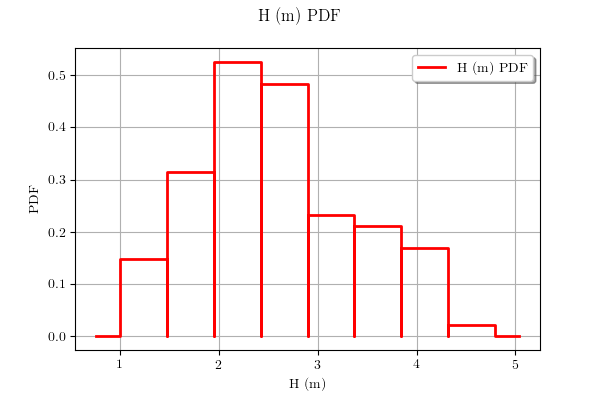

In [14]:
ot.HistogramFactory().build(outputH).drawPDF()

Generate the observation noise and add it to the output of the model.

In [15]:
sigmaObservationNoiseH = 0.1  # (m)
noiseH = ot.Normal(0.0, sigmaObservationNoiseH)
sampleNoiseH = noiseH.getSample(nbobs)
Hobs = outputH + sampleNoiseH

Plot the Y observations versus the X observations.

In [16]:
Qobs = inputSample[:, 0]

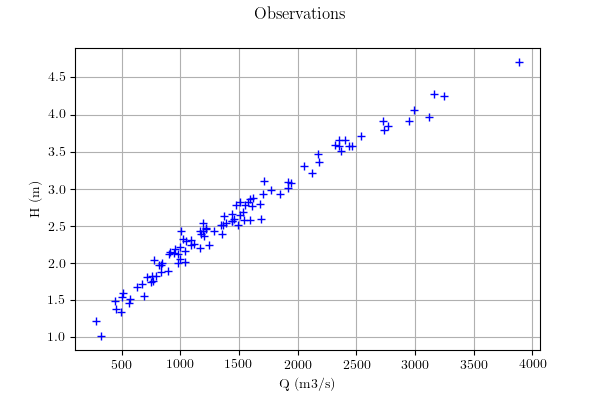

In [17]:
graph = ot.Graph("Observations", "Q (m3/s)", "H (m)", True)
cloud = ot.Cloud(Qobs, Hobs)
graph.add(cloud)
graph

## Setting the calibration parameters

Define the value of the reference values of the $\theta$ parameter. In the bayesian framework, this is called the mean of the *prior* gaussian distribution. In the data assimilation framework, this is called the *background*.

In [18]:
KsInitial = 20.0
ZvInitial = 49.0
ZmInitial = 51.0
thetaPrior = ot.Point([KsInitial, ZvInitial, ZmInitial])

The following statement create the calibrated function from the model. The calibrated parameters Ks, Zv, Zm are at indices 1, 2, 3 in the inputs arguments of the model.

In [19]:
calibratedIndices = [1, 2, 3]
mycf = ot.ParametricFunction(g, calibratedIndices, thetaPrior)
mycf.setParameterDescription(["Ks", "Zv", "Zm"])

## Calibration with linear least squares

Defined the covariance matrix of the parameters $\theta$ to calibrate.

The `LinearLeastSquaresCalibration` class performs the linear least squares calibration by linearizing the model in the neighbourhood of the reference point.

In [20]:
algo = ot.LinearLeastSquaresCalibration(mycf, Qobs, Hobs, thetaPrior, "SVD")

The `run` method computes the solution of the problem.

In [21]:
algo.run()

In [22]:
calibrationResult = algo.getResult()

The `getParameterMAP` method returns the maximum of the posterior distribution of $\theta$.

In [23]:
thetaMAP_LLS = calibrationResult.getParameterMAP()
thetaMAP_LLS

class=Point name=Unnamed dimension=3 values=[-1.0151e+08,3.02498e+23,3.02498e+23]

In this case, we see that there seems to be a great distance from the reference value of $\theta$ to the optimum: the values seem too large in magnitude. The value of the optimum $K_s$ is nonpositive. In fact, there is an identification problem because the Jacobian matrix is rank-degenerate.

## Diagnostic of the identification issue

In this section, we show how to diagnose the identification problem.

The `getParameterPosterior` method returns the posterior gaussian distribution of $\theta$.

In [24]:
distributionPosterior = calibrationResult.getParameterPosterior()
distributionPosterior

class=Normal name=Normal dimension=3 mean=class=Point name=Unnamed dimension=3 values=[-1.0151e+08,3.02498e+23,3.02498e+23] sigma=class=Point name=Unnamed dimension=3 values=[7.33033e+25,5.76275e+31,5.76275e+31] correlationMatrix=class=CorrelationMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[1,2.24407e-25,-2.24407e-25,2.24407e-25,1,1,-2.24407e-25,1,1]

We see that there is a large covariance matrix diagonal. 

Let us compute a 95% confidence interval for the solution $\theta^\star$.

In [25]:
thetaCI_LLS = distributionPosterior.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]
thetaCI_LLS

class=Interval name=Unnamed dimension=3 lower bound=class=Point name=Unnamed dimension=3 values=[-1.63874e+26,-1.2883e+32,-1.2883e+32] upper bound=class=Point name=Unnamed dimension=3 values=[1.63874e+26,1.2883e+32,1.2883e+32] finite lower bound=[1,1,1] finite upper bound=[1,1,1]

The confidence interval is *very* large.

In [26]:
mycf.setParameter(thetaPrior)
thetaDim = thetaPrior.getDimension()
jacobianMatrix = ot.Matrix(nbobs, thetaDim)
for i in range(nbobs):
    jacobianMatrix[i, :] = mycf.parameterGradient(Qobs[i]).transpose()
jacobianMatrix[0:5, :]

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=5 columns=3 values=[-0.133438,-0.170638,-0.0808351,-0.0546252,-0.105857,0.667192,0.853188,0.404175,0.273126,0.529285,-0.667192,-0.853188,-0.404175,-0.273126,-0.529285]

In [27]:
jacobianMatrix.computeSingularValues()

class=Point name=Unnamed dimension=3 values=[9.72877,1.6948e-10,2.04488e-25]

We can see that the singular values associated with $Z_v$ and $Z_m$ are relatively close to zero, compared to the singular value associated with $K_s$. 

This explains why the Jacobian matrix is close to being rank-degenerate.

In other words, the value of $K_s$ can be calibrated, but not $Z_v$ or $Z_m$. 

## Conclusion of the linear least squares calibration

There are several methods to solve the problem.

* Given that the problem is not identifiable, we can use some regularization method. Two methods are provided in the library: the gaussian linear least squares `GaussianLinearCalibration` and the gaussian non linear least squares `GaussianNonlinearCalibration'.
* We can change the problem, replacing it with a problem which is identifiable. In the flooding model, replacing $Z_v-Z_m$ with $\Delta Z$ allows to solve the issue.

## Calibration with non linear least squares

The `NonLinearLeastSquaresCalibration` class performs the non linear least squares calibration by minimizing the squared euclidian norm between the predictions and the observations.

In [28]:
algo = ot.NonLinearLeastSquaresCalibration(mycf, Qobs, Hobs, thetaPrior)

The `run` method computes the solution of the problem.

In [29]:
algo.run()

In [30]:
calibrationResult = algo.getResult()

## Analysis of the results

The `getParameterMAP` method returns the maximum of the posterior distribution of $\theta$.

In [31]:
thetaMAP_NLLS = calibrationResult.getParameterMAP()
thetaMAP_NLLS

class=Point name=Unnamed dimension=3 values=[27.7666,47.0271,52.9729]

We can compute a 95% confidence interval of the parameter $\theta^\star$. 

This confidence interval is based on bootstrap, based on a sample size equal to 100 (as long as the value of the ResourceMap key "NonLinearLeastSquaresCalibration-BootstrapSize" is unchanged). This confidence interval reflects the sensitivity of the optimum to the observations.

In [32]:
thetaPosterior = calibrationResult.getParameterPosterior()
thetaCI_NLLS = thetaPosterior.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]
thetaCI_NLLS

class=Interval name=Unnamed dimension=3 lower bound=class=Point name=Unnamed dimension=3 values=[27.5899,46.963,52.8972] upper bound=class=Point name=Unnamed dimension=3 values=[27.9164,47.1028,53.037] finite lower bound=[1,1,1] finite upper bound=[1,1,1]

In this case, the value of the parameter $K_s$ is quite accurately computed, but there is a relatively large uncertainty on the values of $Z_v$ and $Z_m$.

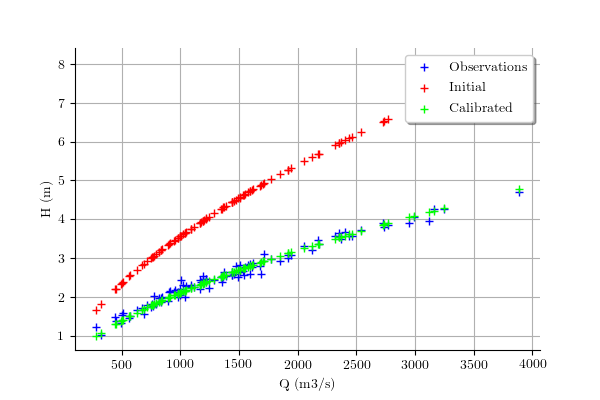

In [33]:
calibrationResult.drawObservationsVsInputs()

We see that there is a good fit after calibration, since the predictions after calibration (i.e. the green crosses) are close to the observations (i.e. the blue crosses).

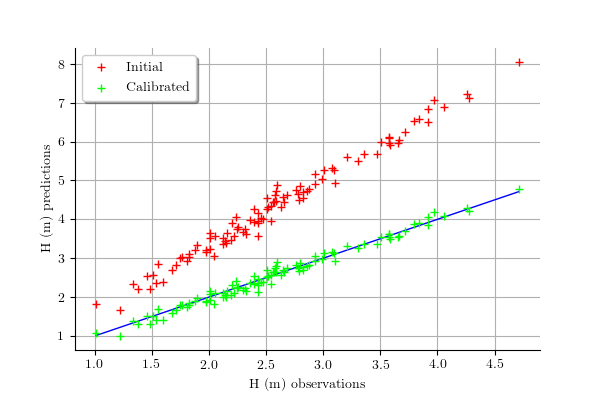

In [34]:
calibrationResult.drawObservationsVsPredictions()

We see that there is a much better fit after calibration, since the predictions are close to the diagonal of the graphics.

In [35]:
observationError = calibrationResult.getObservationsError()
observationError

class=Normal name=Normal dimension=1 mean=class=Point name=Unnamed dimension=1 values=[-0.00982925] sigma=class=Point name=Unnamed dimension=1 values=[0.107724] correlationMatrix=class=CorrelationMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[1]

We can see that the observation error is close to have a zero mean and a standard deviation equal to 0.1.

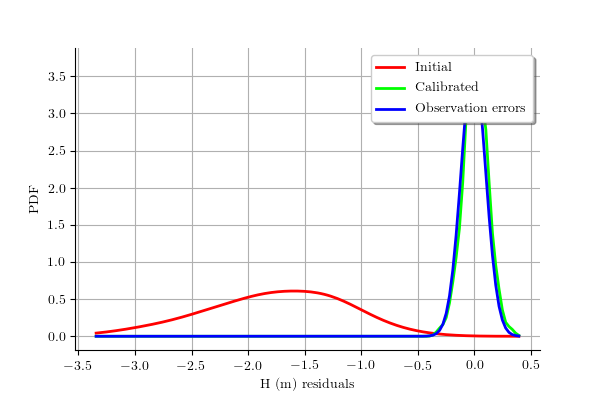

In [36]:
calibrationResult.drawResiduals()

The analysis of the residuals shows that the distribution is centered on zero and symmetric. This indicates that the calibration performed well. 

Moreover, the distribution of the residuals is close to being gaussian.

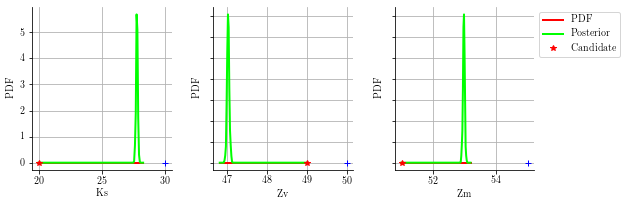

In [37]:
parameter_dimension = mycf.getParameterDimension()
grid = calibrationResult.drawParameterDistributions()
# Add true values
for i in range(parameter_dimension):
    graph = grid.getGraph(0, i)
    cloud = ot.Cloud([theta_true[i]], [0.0])
    cloud.setLegend("True")
    graph.add(cloud)
    grid.setGraph(0, i, graph)
grid.setLegendPosition("")
view = otw.View(grid)
legends = ["PDF", "Posterior", "Candidate"]
set_figure_size(view, width=9.0, height=3.0)
pl.subplots_adjust(wspace=0.3)
_ = pl.legend(legends, bbox_to_anchor=(1.0, 1.0))

In [38]:
algo.getBootstrapSize()

100

## Tuning the posterior distribution estimation


In [39]:
algo.setBootstrapSize(0)

In [40]:
algo.run()

In [41]:
calibrationResult = algo.getResult()

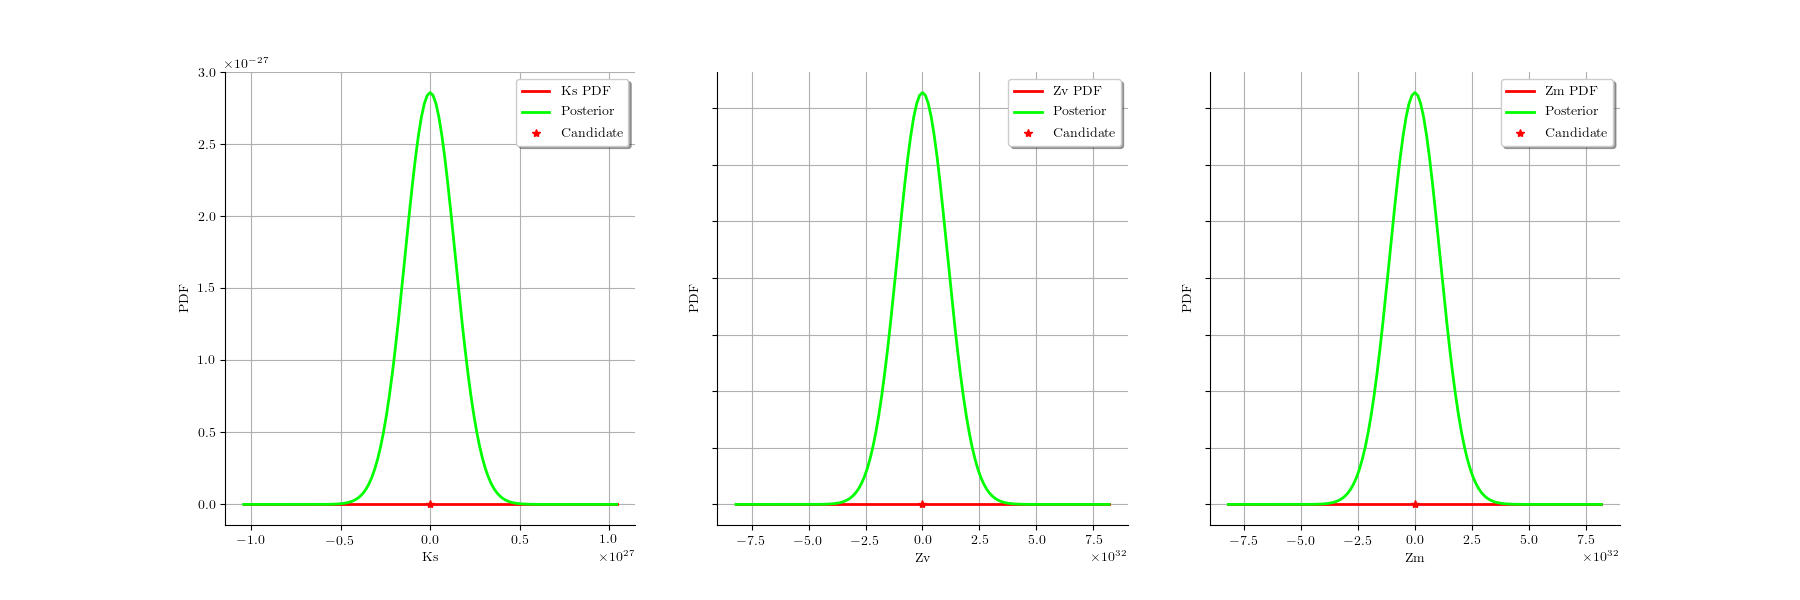

In [42]:
calibrationResult.drawParameterDistributions()

La distribution n'est pas identifiable lorsque l'approximation linéaire est utilisée.

## Analyse en fonction de la taille de l'échantillon

In [43]:
def nonlinear_LS_compute_parameter_resample(number_of_observations = 100):
    inputSample = inputRandomVector.getSample(number_of_observations)
    outputH = g(inputSample)
    sigmaObservationNoiseH = 0.1  # (m)
    noiseH = ot.Normal(0.0, sigmaObservationNoiseH)
    sampleNoiseH = noiseH.getSample(number_of_observations)
    Hobs = outputH + sampleNoiseH
    Qobs = inputSample[:, 0]
    # Solve
    algo = ot.NonLinearLeastSquaresCalibration(mycf, Qobs, Hobs, thetaPrior)
    algo.setBootstrapSize(0)
    algo.run()
    calibrationResult = algo.getResult()
    thetaMAP_NLLS = calibrationResult.getParameterMAP()
    return thetaMAP_NLLS

In [44]:
parameter_dimension = mycf.getParameterDimension()
number_of_repetitions = 100
number_of_observations = 100
parameter_sample = ot.Sample(number_of_repetitions, parameter_dimension)
for i in tqdm.tqdm(range(number_of_repetitions)):
    parameter = nonlinear_LS_compute_parameter_resample(number_of_observations)
    parameter_sample[i] = parameter

 25%|████████████████████▎                                                            | 25/100 [00:00<00:02, 31.99it/s]C:\Users\c61372\Miniconda3482\lib\site-packages\ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in double_scalars
  if __name__ == '__main__':
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 33.01it/s]


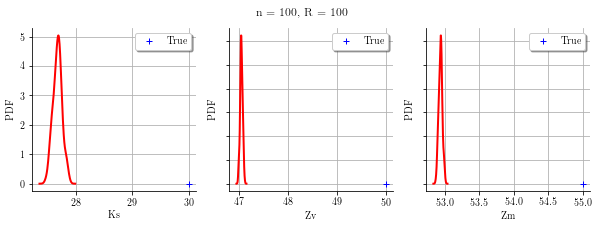

In [45]:
parameter_description = mycf.getParameterDescription()
grid = ot.GridLayout(1, parameter_dimension)
for i in range(parameter_dimension):
    graph = ot.KernelSmoothing().build(parameter_sample[:, i]).drawPDF()
    graph.setLegends([""])
    graph.setXTitle(parameter_description[i])
    grid.setGraph(0, i, graph)
# Add true values
for i in range(parameter_dimension):
    graph = grid.getGraph(0, i)
    cloud = ot.Cloud([theta_true[i]], [0.0])
    cloud.setLegend("True")
    graph.add(cloud)
    grid.setGraph(0, i, graph)
view = otw.View(grid)
_ = set_figure_size(view, width = 10.0, height = 3.0)
figure = view.getFigure()
_ = pl.suptitle("n = %d, R = %d" % (number_of_observations, number_of_repetitions))

## Experiment different starting points

In [46]:
def nonlinear_LS_compute_parameter_starting_point(number_of_observations = 100):
    inputSample = inputRandomVector.getSample(number_of_observations)
    outputH = g(inputSample)
    sigmaObservationNoiseH = 0.1  # (m)
    noiseH = ot.Normal(0.0, sigmaObservationNoiseH)
    sampleNoiseH = noiseH.getSample(number_of_observations)
    Hobs = outputH + sampleNoiseH
    Qobs = inputSample[:, 0]
    # Solve
    algo = ot.NonLinearLeastSquaresCalibration(mycf, Qobs, Hobs, thetaPrior)
    number_of_starting_points = ot.ResourceMap_GetAsUnsignedInteger(
        "NonLinearLeastSquaresCalibration-MultiStartSize"
    )
    parameter_dimension = mycf.getParameterDimension()
    sampling_distribution = ot.Normal(thetaPrior, ot.CovarianceMatrix(parameter_dimension))
    experiment = ot.LowDiscrepancyExperiment(
        ot.SobolSequence(), sampling_distribution, number_of_starting_points
    )
    starting_point_sample = experiment.generate()
    multistart = ot.MultiStart(ot.TNC(), starting_point_sample)
    algo.setOptimizationAlgorithm(multistart)
    algo.setBootstrapSize(0)
    algo.run()
    calibrationResult = algo.getResult()
    thetaMAP_NLLS = calibrationResult.getParameterMAP()
    return thetaMAP_NLLS

In [47]:
parameter_dimension = mycf.getParameterDimension()
number_of_repetitions = 100
number_of_observations = 100
parameter_sample = ot.Sample(number_of_repetitions, parameter_dimension)
for i in tqdm.tqdm(range(number_of_repetitions)):
    parameter = nonlinear_LS_compute_parameter_starting_point(number_of_observations)
    parameter_sample[i] = parameter

 14%|███████████▎                                                                     | 14/100 [00:09<00:52,  1.64it/s]C:\Users\c61372\Miniconda3482\lib\site-packages\ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in double_scalars
  if __name__ == '__main__':
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:03<00:00,  1.57it/s]


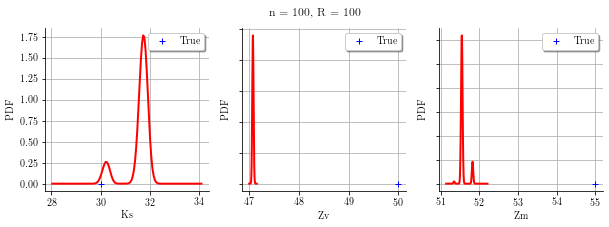

In [48]:
parameter_description = mycf.getParameterDescription()
grid = ot.GridLayout(1, parameter_dimension)
for i in range(parameter_dimension):
    graph = ot.KernelSmoothing().build(parameter_sample[:, i]).drawPDF()
    graph.setLegends([""])
    graph.setXTitle(parameter_description[i])
    grid.setGraph(0, i, graph)
# Add true values
for i in range(parameter_dimension):
    graph = grid.getGraph(0, i)
    cloud = ot.Cloud([theta_true[i]], [0.0])
    cloud.setLegend("True")
    graph.add(cloud)
    grid.setGraph(0, i, graph)
view = otw.View(grid)
_ = set_figure_size(view, width = 10.0, height = 3.0)
figure = view.getFigure()
_ = pl.suptitle("n = %d, R = %d" % (number_of_observations, number_of_repetitions))